### 13. Datasetet "hr_employee_data.xlsx" innehåller data kopplat till ett företags anställda. Gör en *EDA* och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen. I denna uppgift ska ingen ML-modellering göras (det kommer göras i nästa kapitel). Syftet är dels att träna på att genomföra analyser dels att demonstrera hur mycket man kan göra även utan ML-modellering.  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../../data/hr_employee_data.xlsx")
print(f"Totalt anställda: {len(df)}")

Totalt anställda: 14999


In [23]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.5 MB


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [35]:
print("\nKolumner:")
print(df.columns.tolist())


Kolumner:
['Emp_Id', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


In [9]:
print("\nSaknade värden:")
print(df.isnull().sum())


Saknade värden:
Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64


In [27]:
print(df["Department"].value_counts())

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


In [28]:
print(df["salary"].value_counts())

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


In [ ]:
print("\nLämnade jobbet")
print("Ja:", (df["left"] == 1).sum())
print("Nej:", (df["left"] == 0).sum())


Lämnade jobbet
Ja: 3571
Nej: 11428


In [38]:
print("\nLöner och turnover:")
for sal in ["low", "medium", "high"]:
    count = (df["salary"] == sal).sum()
    left = ((df["salary"] == sal) & (df["left"] == 1)).sum()
    pct = left / count * 100
    print(sal + ": " + str(int(pct)) + "% lämnade")


Löner och turnover:
low: 29% lämnade
medium: 20% lämnade
high: 6% lämnade


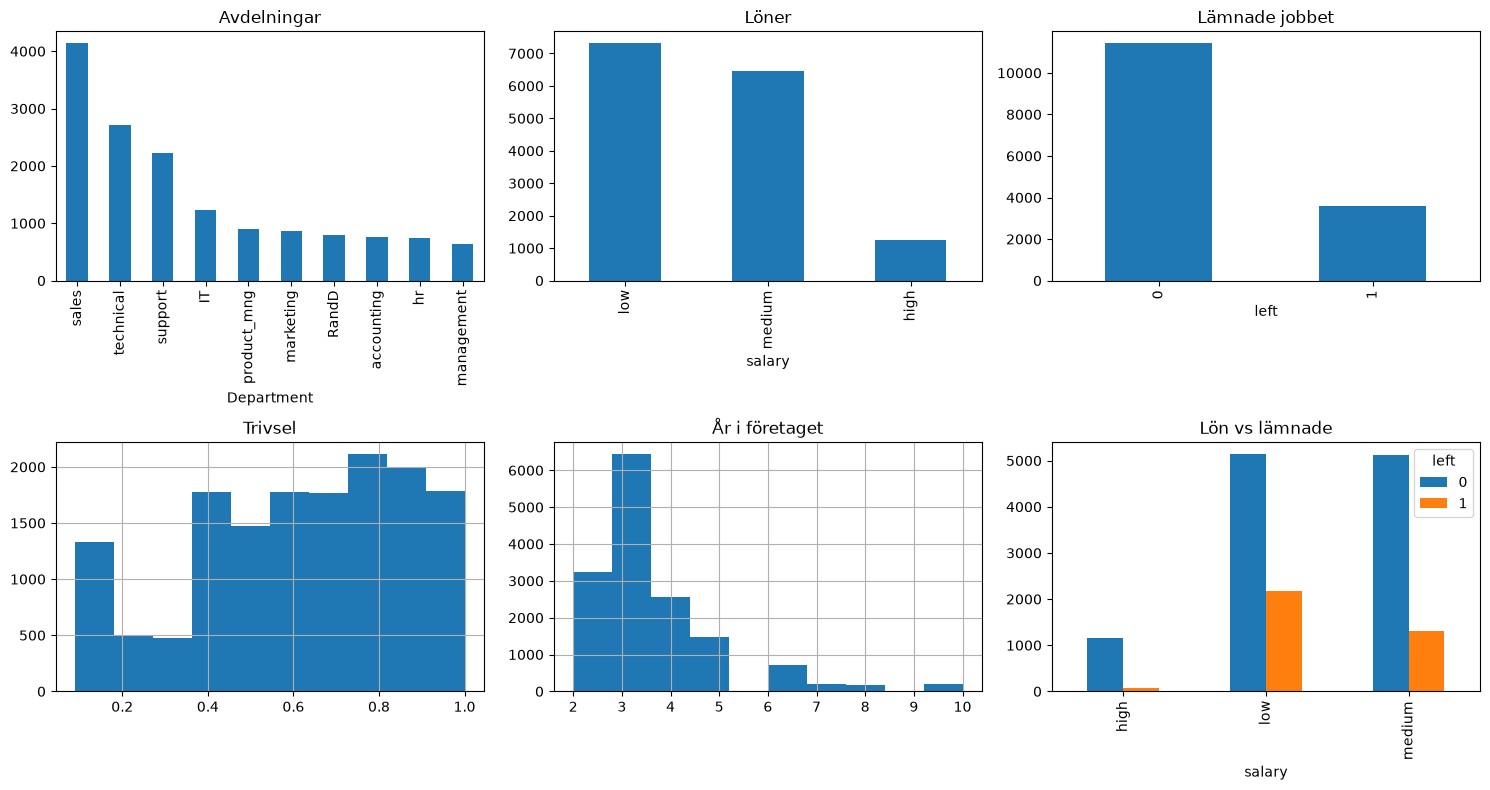

In [32]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

df["Department"].value_counts().plot(kind="bar", ax=axs[0, 0])
axs[0, 0].set_title("Avdelningar")

df["salary"].value_counts().plot(kind="bar", ax=axs[0, 1])
axs[0, 1].set_title("Löner")

df["left"].value_counts().plot(kind="bar", ax=axs[0, 2])
axs[0, 2].set_title("Lämnade jobbet")

df["satisfaction_level"].hist(ax=axs[1, 0])
axs[1, 0].set_title("Trivsel")

df["time_spend_company"].hist(ax=axs[1, 1])
axs[1, 1].set_title("År i företaget")

pd.crosstab(df["salary"], df["left"]).plot(kind="bar", ax=axs[1, 2])
axs[1, 2].set_title("Lön vs lämnade")

plt.tight_layout()
plt.show()

In [39]:
print("\nProcent beräkning:")
low = (df["salary"] == "low").sum()
med = (df["salary"] == "medium").sum()
high = (df["salary"] == "high").sum()
tot = len(df)

print("Låga: " + str(low) + " av " + str(tot) + " = " + str(int(low / tot * 100)) + "%")
print(
    "Medium: " + str(med) + " av " + str(tot) + " = " + str(int(med / tot * 100)) + "%"
)
print(
    "Höga: " + str(high) + " av " + str(tot) + " = " + str(int(high / tot * 100)) + "%"
)


Procent beräkning:
Låga: 7316 av 14999 = 48%
Medium: 6446 av 14999 = 42%
Höga: 1237 av 14999 = 8%


## Mina slutsatser

- Sales är den största avdelningen med 4140 anställda, följt av technical (2720) och support (2229)
- Majoriteten av anställda har låg lön (7316 anställda = 48%), medan endast 1237 har hög lön (8%)
- De som är medium-lönade utgör 42% av anställda (6446 personer)
- Det finns totalt 14999 anställda i datasetet
